**Plant Village**

Importando data (descomprimo en colab) y verificando que se carguen todas las imágenes

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'PlantVillage.zip', 'vgg16_warmup_phase1.h5', 'vgg16_warmup_phase1.keras', 'history_phase1.csv', 'vgg16_warmup_final.keras', 'history_phase2.csv', 'vgg16_warmup_test_results.csv']


In [3]:
!unzip -q "/content/drive/MyDrive/PlantVillage.zip" -d "/content/plantdisease"

In [4]:
import os

print(os.listdir("/content/plantdisease"))

['plantvillage', 'PlantVillage']


In [5]:
import os

print("PlantVillage:")
print(os.listdir("/content/plantdisease/PlantVillage")[:10])

print("\nplantvillage:")
print(os.listdir("/content/plantdisease/plantvillage")[:10])

PlantVillage:
['Tomato_Bacterial_spot', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy', 'Pepper__bell___healthy', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Potato___Early_blight']

plantvillage:
['PlantVillage']


In [6]:
DATA_DIR = "/content/plantdisease/PlantVillage"

import os
print(len(os.listdir(DATA_DIR)))

15


In [7]:
import os

total = 0

for folder in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(folder_path):
        num_images = len([
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        total += num_images
        print(f"{folder}: {num_images} imágenes")

print("\nTotal imágenes:", total)

Tomato_Bacterial_spot: 2127 imágenes
Potato___Late_blight: 1000 imágenes
Pepper__bell___Bacterial_spot: 997 imágenes
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 imágenes
Tomato_healthy: 1591 imágenes
Pepper__bell___healthy: 1478 imágenes
Potato___healthy: 152 imágenes
Tomato_Early_blight: 1000 imágenes
Tomato_Late_blight: 1909 imágenes
Potato___Early_blight: 1000 imágenes
Tomato_Septoria_leaf_spot: 1771 imágenes
Tomato__Tomato_mosaic_virus: 373 imágenes
Tomato__Target_Spot: 1404 imágenes
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 imágenes
Tomato_Leaf_Mold: 952 imágenes

Total imágenes: 20638


Transformando a binario

In [8]:
import pandas as pd
import os

image_paths = []
labels = []
class_names = []

for folder in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(folder_path):
        #Reminder: 0 = sana, 1 = enfema
        label = 0 if "healthy" in folder.lower() else 1

        for file in os.listdir(folder_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
                class_names.append(folder)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
    "original_class": class_names
})

df.head()

,image_path,label,original_class
0,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
1,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
2,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
3,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
4,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot


In [9]:
df["label"].value_counts()

,count
label,
1,17417
0,3221


In [10]:
df["label"].value_counts(normalize=True)

,proportion
label,
1,0.843929
0,0.156071


Separando datasets

In [11]:
from sklearn.model_selection import train_test_split

#test (15%)
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

#validación (15% de lo que queda)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 14910
Validation: 2632
Test: 3096


In [12]:
print("Train:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest:")
print(test_df["label"].value_counts(normalize=True))

Train:
label
1    0.84393
0    0.15607
Name: proportion, dtype: float64

Validation:
label
1    0.843845
0    0.156155
Name: proportion, dtype: float64

Test:
label
1    0.843992
0    0.156008
Name: proportion, dtype: float64


VGG16

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 14910 validated image filenames.
Found 2632 validated image filenames.
Found 3096 validated image filenames.


In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print(class_weights)

{0: np.float64(3.203695745595187), 1: np.float64(0.5924660255900819)}


Crear fase 1

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

#VGG16 preentrenado en ImageNet
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

#fase 1 warm-up: freeze VGG16
base_model.trainable = False

#para clasificación binaria
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Entrenar fase 1

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_recall",
    patience=2,
    mode="max",
    restore_best_weights=True
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 269s 546ms/step - accuracy: 0.6453 - loss: 0.6913 - precision: 0.8582 - recall: 0.6945 - val_accuracy: 0.8214 - val_loss: 0.6239 - val_precision: 0.9003 - val_recall: 0.8865
Epoch 2/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 270s 579ms/step - accuracy: 0.6991 - loss: 0.6315 - precision: 0.9218 - recall: 0.7030 - val_accuracy: 0.8385 - val_loss: 0.5845 - val_precision: 0.9504 - val_recall: 0.8532
Epoch 3/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 233s 499ms/step - accuracy: 0.7714 - loss: 0.5823 - precision: 0.9516 - recall: 0.7682 - val_accuracy: 0.8393 - val_loss: 0.5452 - val_precision: 0.9518 - val_recall: 0.8528


In [ ]:
model.save("/content/drive/MyDrive/vgg16_warmup_phase1.keras")

import pandas as pd

pd.DataFrame(history_phase1.history).to_csv(
    "/content/drive/MyDrive/history_phase1.csv",
    index=False
)

Fase 2

In [ ]:
#Unfreeze VGG16 (hacerlo entrenable)
base_model.trainable = True

#Freeze (tpdo menos las últimas 4 capas convolucionales)
for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

#Imprime capas entrenables
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 7,079,937 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Entrenar fase 2

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_recall",
    patience=2,
    mode="max",
    restore_best_weights=True
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 252s 526ms/step - accuracy: 0.9165 - loss: 0.2047 - precision: 0.9868 - recall: 0.9133 - val_accuracy: 0.9384 - val_loss: 0.1451 - val_precision: 0.9976 - val_recall: 0.9293
Epoch 2/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 240s 514ms/step - accuracy: 0.9586 - loss: 0.1035 - precision: 0.9945 - recall: 0.9562 - val_accuracy: 0.9472 - val_loss: 0.1260 - val_precision: 0.9990 - val_recall: 0.9383
Epoch 3/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 238s 512ms/step - accuracy: 0.9690 - loss: 0.0807 - precision: 0.9960 - recall: 0.9672 - val_accuracy: 0.9859 - val_loss: 0.0466 - val_precision: 0.9923 - val_recall: 0.9910
Epoch 4/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 237s 508ms/step - accuracy: 0.9753 - loss: 0.0669 - precision: 0.9967 - recall: 0.9739 - val_accuracy: 0.9791 - val_loss: 0.0528 - val_precision: 0.9982 - val_recall: 0.9770
Epoch 5/5
466/466 ━━━━━━━━━━━━━━━━━━━━ 238s 510ms/step - accuracy: 0.9774 - loss: 0.0559 - precision: 0.9974 - recall: 0.9758 - val_accuracy: 0.9472

In [ ]:
model.save("/content/drive/MyDrive/vgg16_warmup_final.keras")

import pandas as pd

pd.DataFrame(history_phase2.history).to_csv(
    "/content/drive/MyDrive/history_phase2.csv",
    index=False
)

Probando en set de test

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test precision:", test_precision)
print("Test recall:", test_recall)

97/97 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.9767 - loss: 0.0594 - precision: 0.9873 - recall: 0.9851
Test loss: 0.0594489723443985
Test accuracy: 0.9767441749572754
Test precision: 0.9873417615890503
Test recall: 0.9850746393203735


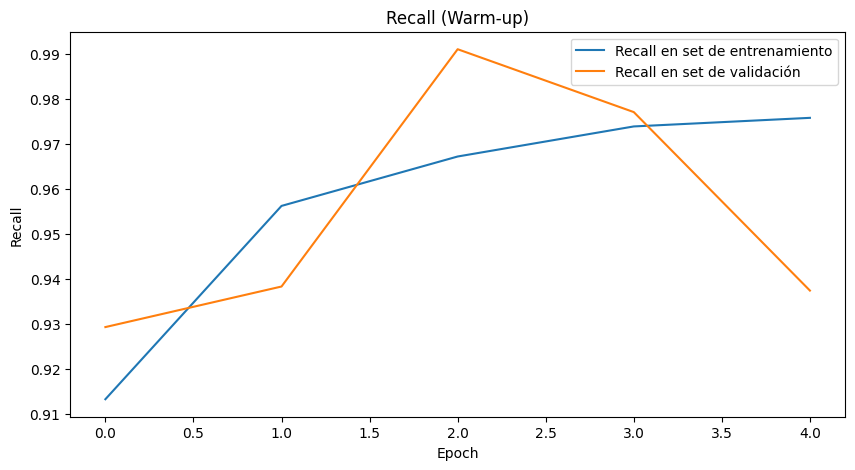

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(phase2["recall"], label="Recall en set de entrenamiento")
plt.plot(phase2["val_recall"], label="Recall en set de validación")

plt.title("Recall (Warm-up)")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [ ]:
test_results = pd.DataFrame([{
    "Modelo": "VGG16",
    "Estrategia": "Warm-up",
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": f1
}])

test_results.to_csv(
    "/content/drive/MyDrive/vgg16_warmup_test_results.csv",
    index=False
)

import pandas as pd

phase1 = pd.read_csv("/content/drive/MyDrive/history_phase1.csv")
phase2 = pd.read_csv("/content/drive/MyDrive/history_phase2.csv")

best_phase1 = phase1.loc[phase1["val_recall"].idxmax()]
best_phase2 = phase2.loc[phase2["val_recall"].idxmax()]

results = pd.DataFrame([
    {
        "Arquitectura": "VGG16",
        "Transfer Learning": "Warm-up (fase 1)",
        "Accuracy": best_phase1["val_accuracy"],
        "Precision": best_phase1["val_precision"],
        "Recall": best_phase1["val_recall"]
    },
    {
        "Arquitectura": "VGG16",
        "Transfer Learning": "Warm-up (fase 2)",
        "Accuracy": best_phase2["val_accuracy"],
        "Precision": best_phase2["val_precision"],
        "Recall": best_phase2["val_recall"]
    },
    {
        "Arquitectura": "VGG16",
        "Transfer Learning": "Warm-up (test)",
        "Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall
    }
])

results

,Arquitectura,Transfer Learning,Accuracy,Precision,Recall
0,VGG16,Warm-up (fase 1),0.892857,0.960570,0.910401
1,VGG16,Warm-up (fase 2),0.985942,0.992335,0.990995
2,VGG16,Warm-up (test),0.976744,0.987342,0.985075


Matriz de confusión

97/97 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step


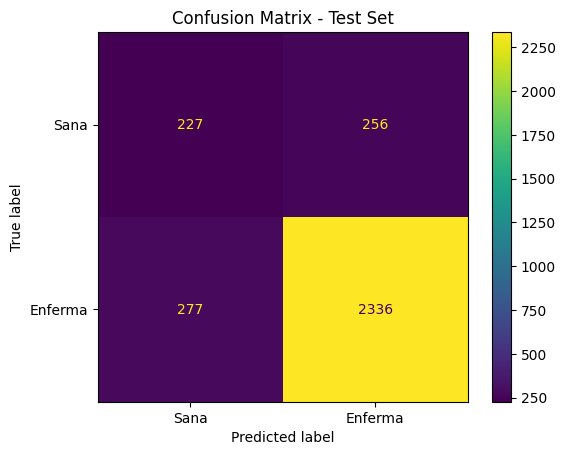

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

test_generator.reset()

y_prob = model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).ravel()

y_true = test_generator.labels

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sana", "Enferma"]
)

disp.plot(values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.show()